In [1]:
from transformers import AutoModelForCausalLM, AutoTokenizer, AutoConfig
import torch

xlstm_config = AutoConfig.from_pretrained("NX-AI/xLSTM-7b")
xlstm_config.step_kernel = "native"
xlstm_config.chunkwise_kernel = "chunkwise--native_autograd"
xlstm_config.sequence_kernel = "native_sequence__native"

model = AutoModelForCausalLM.from_pretrained("NX-AI/xLSTM-7b",
                                             config=xlstm_config, device_map="auto")

# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained("NX-AI/xLSTM-7b")

# Your prompt
prompt = "The quick brown fox jumps over the lazy dog."

# Tokenize and send to the same device as the model
inputs = tokenizer(prompt, return_tensors="pt")['input_ids'].to(model.device)

# Get the BOS token ID from the tokenizer
bos_id = tokenizer.bos_token_id

# Prepend BOS
bos_tensor = torch.tensor([[bos_id]], device=model.device, dtype=inputs.dtype)
tokens_with_bos = torch.cat([bos_tensor, inputs], dim=1)

# Generate
with torch.no_grad():
    outputs = model(tokens_with_bos, output_hidden_states=True)

hidden_states = outputs.hidden_states



d:\A_Facultate\Diseration\code\Dissertation-code\logit_lens\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 483/483 [00:54<00:00,  8.82it/s] 
Some parameters are on the meta device because they were offloaded to the cpu and disk.


In [2]:
print(model)

xLSTMForCausalLM(
  (backbone): xLSTMModel(
    (embeddings): Embedding(50304, 4096)
    (blocks): ModuleList(
      (0-31): 32 x xLSTMBlock(
        (norm_mlstm): xLSTMRMSNorm()
        (mlstm_layer): xLSTMLayer(
          (q): Linear(in_features=4096, out_features=2048, bias=False)
          (k): Linear(in_features=4096, out_features=2048, bias=False)
          (v): Linear(in_features=4096, out_features=4096, bias=False)
          (ogate_preact): Linear(in_features=4096, out_features=4096, bias=False)
          (igate_preact): Linear(in_features=4096, out_features=8, bias=True)
          (fgate_preact): Linear(in_features=4096, out_features=8, bias=True)
          (ogate_act_fn): Sigmoid()
          (mlstm_backend): xLSTMBackend(
            xLSTMConfig {
              "add_embedding_dropout": false,
              "add_forward_backend_padding": false,
              "add_out_norm": true,
              "add_post_blocks_norm": true,
              "add_post_norm": false,
              "a

In [2]:
print(len(hidden_states))

33


In [3]:
FINAL_NORM = model.backbone.out_norm
LM_HEAD = model.lm_head
INPUT_TOKENS = [tokenizer.decode(t).replace("Ġ", "").replace(" ", "") for t in tokenizer(prompt)['input_ids']]

In [4]:
state=hidden_states[20]
logits = LM_HEAD(FINAL_NORM(state))

final_token_logits = logits[0, -1, :]
# Grab the index with the highest number
best_guess_id = torch.argmax(final_token_logits, dim=-1)
print(tokenizer.decode(best_guess_id))

)[$


In [5]:
def extract_top_tokens(lm_head, final_norm, hidden_states, every_other_hidden=True):
    import torch.nn.functional as F
    
    if len(hidden_states) == 1:
        logits = lm_head(final_norm(hidden_states[0]))
        final_token_logits = logits[0, :-1, :]
        probs = F.softmax(final_token_logits, dim=-1)
        max_logits, best_guess_ids = torch.max(probs, dim=-1)
        layer_tokens = [tokenizer.decode(token_id) for token_id in best_guess_ids]
        return [layer_tokens], [max_logits.tolist()]
    
    all_layers_predictions = []
    all_layers_logits = []
    for i, h in enumerate(hidden_states):
        if every_other_hidden and i % 2: 
            continue

        logits = lm_head(final_norm(hidden_states[i]))
        final_token_logits = logits[0, :-1, :]

        probs = F.softmax(final_token_logits, dim=-1)
        max_logits, best_guess_ids = torch.max(probs, dim=-1)
        layer_tokens = [tokenizer.decode(token_id) for token_id in best_guess_ids]

        all_layers_predictions.append(layer_tokens)
        all_layers_logits.append(max_logits.tolist())

    return all_layers_predictions, all_layers_logits

# NOTE: Update the call to pass hidden_states!
top_token_per_block, top_logits_per_block = extract_top_tokens(LM_HEAD, FINAL_NORM, hidden_states)


In [6]:
len(top_token_per_block)

17

In [7]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def plot_table(top_tokens, top_logits, every_other_hidden=True): 
    num_cols = min(len(top_tokens[0]), len(INPUT_TOKENS))

        
    top_headers = INPUT_TOKENS[:num_cols]
    bottom_headers = (["<BOS>"] + INPUT_TOKENS)[:num_cols]
    
    table_data = [row[:num_cols] for row in top_tokens[::-1]] + [bottom_headers]
    logits_data = [row[:num_cols] for row in top_logits[::-1]]
    all_logits = [val for row in logits_data for val in row]
    norm = mcolors.Normalize(vmin=min(all_logits), vmax=max(all_logits))
    import numpy as np
    from matplotlib.colors import ListedColormap
    
    base_cmap = plt.get_cmap('plasma')
    cmap_colors = base_cmap(np.arange(base_cmap.N))
    cmap_colors[:, -1] = 0.75 # Adjust this value (0.0 to 1.0) to change opacity
    cmap = ListedColormap(cmap_colors)
    row_headers = [f"h_{2*i+1:02d}" for i in range(len(top_tokens))][::-1] + ["Input"] if every_other_hidden else \
        [f"h_{i:02d}" for i in range(len(top_tokens))][::-1] + ["Input"]
    
    fig, ax = plt.subplots(figsize=(len(top_headers) * 1.2, len(table_data) * 0.5))
    ax.axis('tight')
    ax.axis('off')
    table = ax.table(
        cellText=table_data,
        rowLabels=row_headers,
        colLabels=top_headers,
        loc='center',
        cellLoc='center'
    )
    table.scale(1, 1.8)
    
    for (row, col), cell in table.get_celld().items():
        if row == 0 or row == len(table_data) or col == -1: 
            cell.set_text_props(weight='bold')
            cell.set_facecolor('#f0f0f0') 
        else:
            val = logits_data[row-1][col]
            r, g, b, a = cmap(norm(val))
            cell.set_facecolor((r, g, b, a))
            if 0.299*r + 0.587*g + 0.114*b < 0.5:
                cell.get_text().set_color('white')
            
            if col < len(top_headers):
                pred_token = str(table_data[row-1][col]).replace("Ġ", "").replace(" ", "")
                target_token = str(top_headers[col]).replace("Ġ", "").replace(" ", "")
                if pred_token == target_token:
                    cell.set_edgecolor('black')
                    cell.set_linewidth(3)
                    cell.set_zorder(10)
                    
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.02, pad=0.04)
    cbar.set_label('Confidence (Probability)')
    plt.savefig("./top_token_prob_per_inner.png")
    plt.show()



C:\Users\flavi\AppData\Local\Temp\ipykernel_7364\1447554656.py:60: UserWarning: Glyph 12400 (\N{HIRAGANA LETTER BA}) missing from font(s) DejaVu Sans.
  plt.savefig("./top_token_prob_per_inner.png")
d:\A_Facultate\Diseration\code\Dissertation-code\logit_lens\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12400 (\N{HIRAGANA LETTER BA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


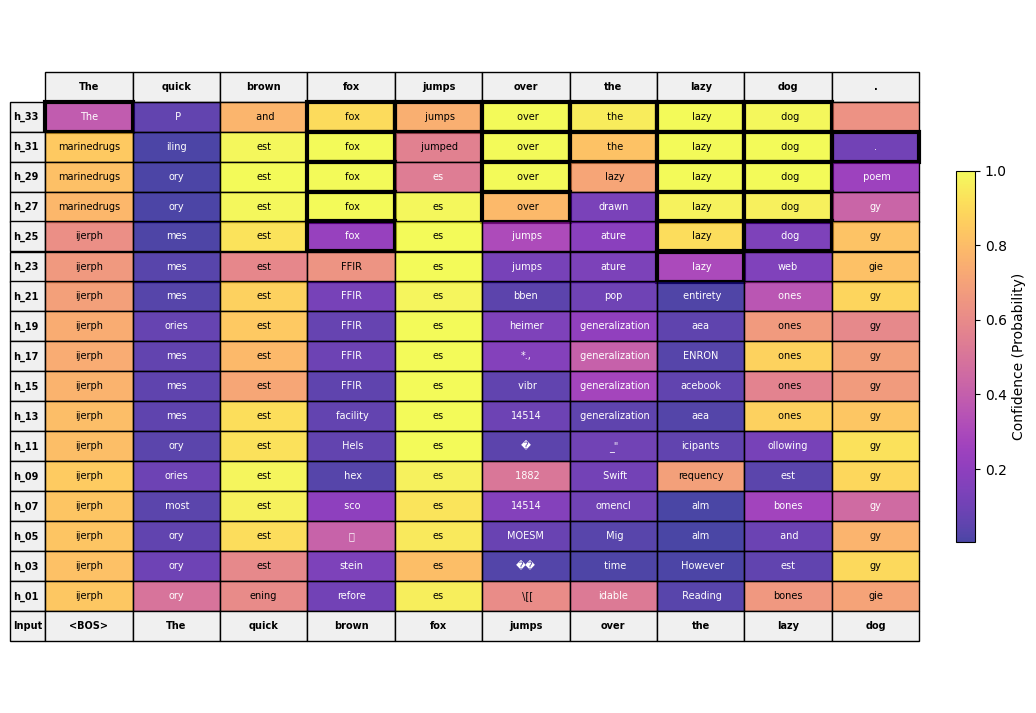

In [8]:
plot_table(top_token_per_block, top_logits_per_block)

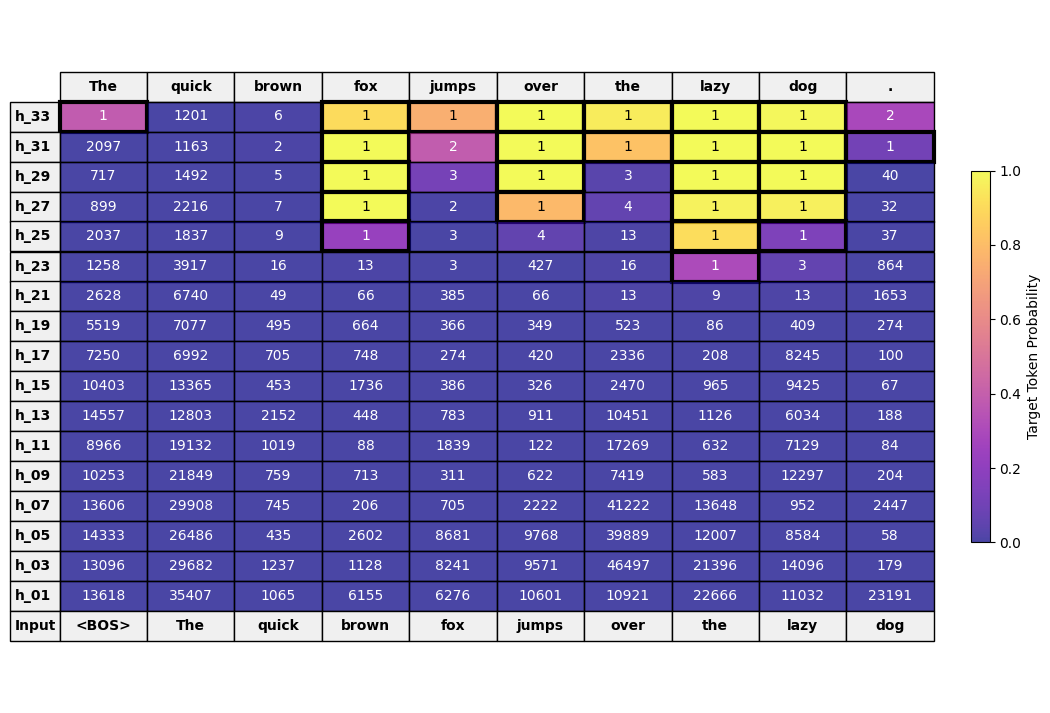

In [9]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from matplotlib.colors import ListedColormap


def get_top_token_ranking_and_probs(state, lm_head, final_norm):
    logits = lm_head(final_norm(state))
    final_token_logits = logits[0, :-1, :]

    probs = F.softmax(final_token_logits, dim=-1)
    
    sorted_probs, sorted_indices = torch.sort(probs, dim=-1, descending=True)
    
    layer_ranks = []
    layer_probs = []
    
    for pos in range(len(target_ids)):
        target_id = target_ids[pos].item()
        rank = (sorted_indices[pos] == target_id).nonzero(as_tuple=True)[0].item() + 1
        prob = probs[pos, target_id].item()
        
        layer_ranks.append(rank)
        layer_probs.append(prob)
    
    return layer_ranks, layer_probs

def extract_target_ranks_and_probs(lm_head, final_norm, hidden_states, target_ids, every_other_hidden=True):
    if len(hidden_states) == 1:
        layer_ranks, layer_probs = get_top_token_ranking_and_probs(hidden_states[0], lm_head, final_norm)

        return [layer_ranks], [layer_probs]
    
    all_layers_ranks = []
    all_layers_probs = []
    
    for i, h in enumerate(hidden_states):
        if every_other_hidden and i % 2: 
            continue
        
        state = hidden_states[i]
        layer_ranks, layer_probs = get_top_token_ranking_and_probs(state, lm_head, final_norm)

        all_layers_ranks.append(layer_ranks)
        all_layers_probs.append(layer_probs)

    return all_layers_ranks, all_layers_probs

def plot_rank_table(ranks_data, probs_data, every_other_hidden=True): 
    if not ranks_data or not ranks_data[0]:
        return
        
    num_cols = min(len(ranks_data[0]), len(INPUT_TOKENS))

        
    top_headers = INPUT_TOKENS[:num_cols]
    bottom_headers = (["<BOS>"] + INPUT_TOKENS)[:num_cols]
    
    table_data = [row[:num_cols] for row in ranks_data[::-1]] + [bottom_headers]
    logits_data = [row[:num_cols] for row in probs_data[::-1]]
    all_logits = [val for row in logits_data for val in row]
    
    norm = mcolors.Normalize(vmin=min(all_logits), vmax=max(all_logits))
    
    base_cmap = plt.get_cmap('plasma')
    cmap_colors = base_cmap(np.arange(base_cmap.N))
    cmap_colors[:, -1] = 0.75
    cmap = ListedColormap(cmap_colors)
    
    row_headers = [f"h_{2*i+1:02d}" for i in range(len(ranks_data))][::-1] + ["Input"] if every_other_hidden else \
        [f"h_{i:02d}" for i in range(len(ranks_data))][::-1] + ["Input"]
    
    fig, ax = plt.subplots(figsize=(len(top_headers) * 1.2, len(table_data) * 0.5))
    ax.axis('tight')
    ax.axis('off')
    
    table = ax.table(
        cellText=table_data,
        rowLabels=row_headers,
        colLabels=top_headers,
        loc='center',
        cellLoc='center'
    )
    table.scale(1, 1.8)
    
    for (row, col), cell in table.get_celld().items():
        if row == 0 or row == len(table_data) or col == -1: 
            cell.set_text_props(weight='bold')
            cell.set_facecolor('#f0f0f0') 
        else:
            val = logits_data[row-1][col]
            r, g, b, a = cmap(norm(val))
            cell.set_facecolor((r, g, b, a))
            
            if 0.299*r + 0.587*g + 0.114*b < 0.5:
                cell.get_text().set_color('white')
            
            if col < len(top_headers):
                cell_rank = table_data[row-1][col]
                if str(cell_rank) == "1":
                    cell.set_edgecolor('black')
                    cell.set_linewidth(3)
                    cell.set_zorder(10)
                    
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.02, pad=0.04)
    cbar.set_label('Target Token Probability')
    plt.savefig("./top_token_ranking_per_hidden.png")
    plt.show()

target_ids = inputs[0]
ranks_per_block, probs_per_block = extract_target_ranks_and_probs(LM_HEAD, FINAL_NORM, hidden_states, target_ids)
plot_rank_table(ranks_per_block, probs_per_block)

In [10]:
import numpy as np 

def kl_div(p, q, axis=-1):
  return np.sum(p*np.log(p/q), axis=axis)

In [11]:
def extract_kl_divergences(lm_head, final_norm, hidden_states, every_other_hidden=True):
    import torch.nn.functional as F
    
    # Calculate the target distribution: the final layer's probabilities.
    # hidden_states[-1] is the output of the last block.
    final_logits = lm_head(final_norm(hidden_states[-1]))
    final_probs = F.softmax(final_logits[0, :-1, :], dim=-1)
    
    if len(hidden_states) == 1:
        logits = lm_head(final_norm(hidden_states[0]))
        layer_probs = F.softmax(logits[0, :-1, :], dim=-1)
        kl = F.kl_div(layer_probs.log(), final_probs, reduction='none').sum(dim=-1)
        return [kl.tolist()]
    
    all_layers_kl = []
    
    for i, h in enumerate(hidden_states):
        if every_other_hidden and i % 2: 
            continue
            
        logits = lm_head(final_norm(hidden_states[i]))
        layer_probs = F.softmax(logits[0, :-1, :], dim=-1)
        
        # KL(P || Q) = sum(P * log(P / Q))
        # F.kl_div(input, target) where input is log-probs and target is probs
        kl = F.kl_div(layer_probs.log(), final_probs, reduction='none').sum(dim=-1)
        all_layers_kl.append(kl.tolist())
        
    return all_layers_kl

kl_per_block = extract_kl_divergences(LM_HEAD, FINAL_NORM, hidden_states)


C:\Users\flavi\AppData\Local\Temp\ipykernel_7364\3987249204.py:62: UserWarning: Glyph 12400 (\N{HIRAGANA LETTER BA}) missing from font(s) DejaVu Sans.
  plt.savefig("./hidden_vs_outpout_KL.png")


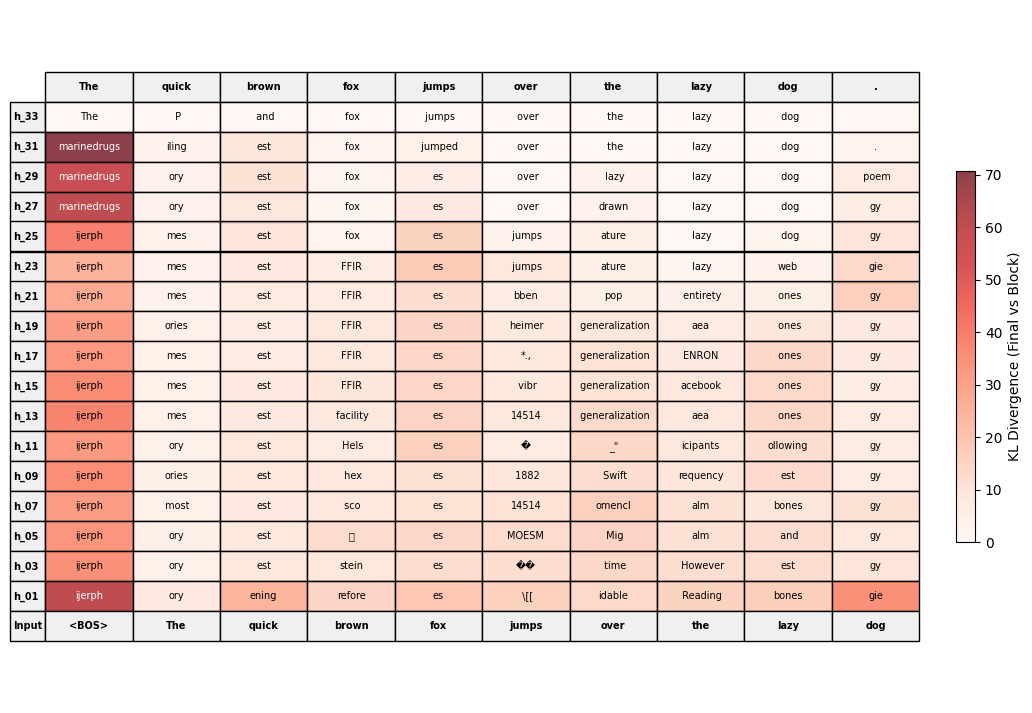

In [12]:
def plot_kl_table(top_tokens, kl_data, every_other_hidden=True): 
    if not top_tokens or not top_tokens[0]:
        return
        
    num_cols = min(len(top_tokens[0]), len(INPUT_TOKENS))
        
    top_headers = INPUT_TOKENS[:num_cols]
    bottom_headers = (["<BOS>"] + INPUT_TOKENS)[:num_cols]
    
    table_data = [row[:num_cols] for row in top_tokens[::-1]] + [bottom_headers]
    kl_values = [row[:num_cols] for row in kl_data[::-1]]
    
    all_kl = [val for row in kl_values for val in row]
    
    # We want 0 KL to be bright (similar to high probability), and high KL to be dark
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors
    import numpy as np
    from matplotlib.colors import ListedColormap
    
    norm = mcolors.Normalize(vmin=min(all_kl), vmax=max(all_kl))
    
    base_cmap = plt.get_cmap('Reds')
    cmap_colors = base_cmap(np.arange(base_cmap.N))
    cmap_colors[:, -1] = 0.75 
    cmap = ListedColormap(cmap_colors)
    
    row_headers = [f"h_{2*i+1:02d}" for i in range(len(top_tokens))][::-1] + ["Input"] if every_other_hidden else \
        [f"h_{i:02d}" for i in range(len(top_tokens))][::-1] + ["Input"]
    
    fig, ax = plt.subplots(figsize=(len(top_headers) * 1.2, len(table_data) * 0.5))
    ax.axis('tight')
    ax.axis('off')
    table = ax.table(
        cellText=table_data,
        rowLabels=row_headers,
        colLabels=top_headers,
        loc='center',
        cellLoc='center'
    )
    table.scale(1, 1.8)
    
    for (row, col), cell in table.get_celld().items():
        if row == 0 or row == len(table_data) or col == -1: 
            cell.set_text_props(weight='bold')
            cell.set_facecolor('#f0f0f0') 
        else:
            val = kl_values[row-1][col]
            r, g, b, a = cmap(norm(val))
            cell.set_facecolor((r, g, b, a))
            if 0.299*r + 0.587*g + 0.114*b < 0.5:
                cell.get_text().set_color('white')
            
            if col < len(top_headers):
                pred_token = str(table_data[row-1][col]).replace("Ġ", "").replace(" ", "")
                target_token = str(top_headers[col]).replace("Ġ", "").replace(" ", "")
                    
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.02, pad=0.04)
    cbar.set_label('KL Divergence (Final vs Block)')
    plt.savefig("./hidden_vs_outpout_KL.png")
    plt.show()

plot_kl_table(top_token_per_block, kl_per_block)

Executing forward pass on pruned model (Embeddings -> Last 25 Blocks -> LM Head)...

--- Experiment 1: Extract Top Tokens ---


C:\Users\flavi\AppData\Local\Temp\ipykernel_7364\1447554656.py:60: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  plt.savefig("./top_token_prob_per_inner.png")
d:\A_Facultate\Diseration\code\Dissertation-code\logit_lens\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


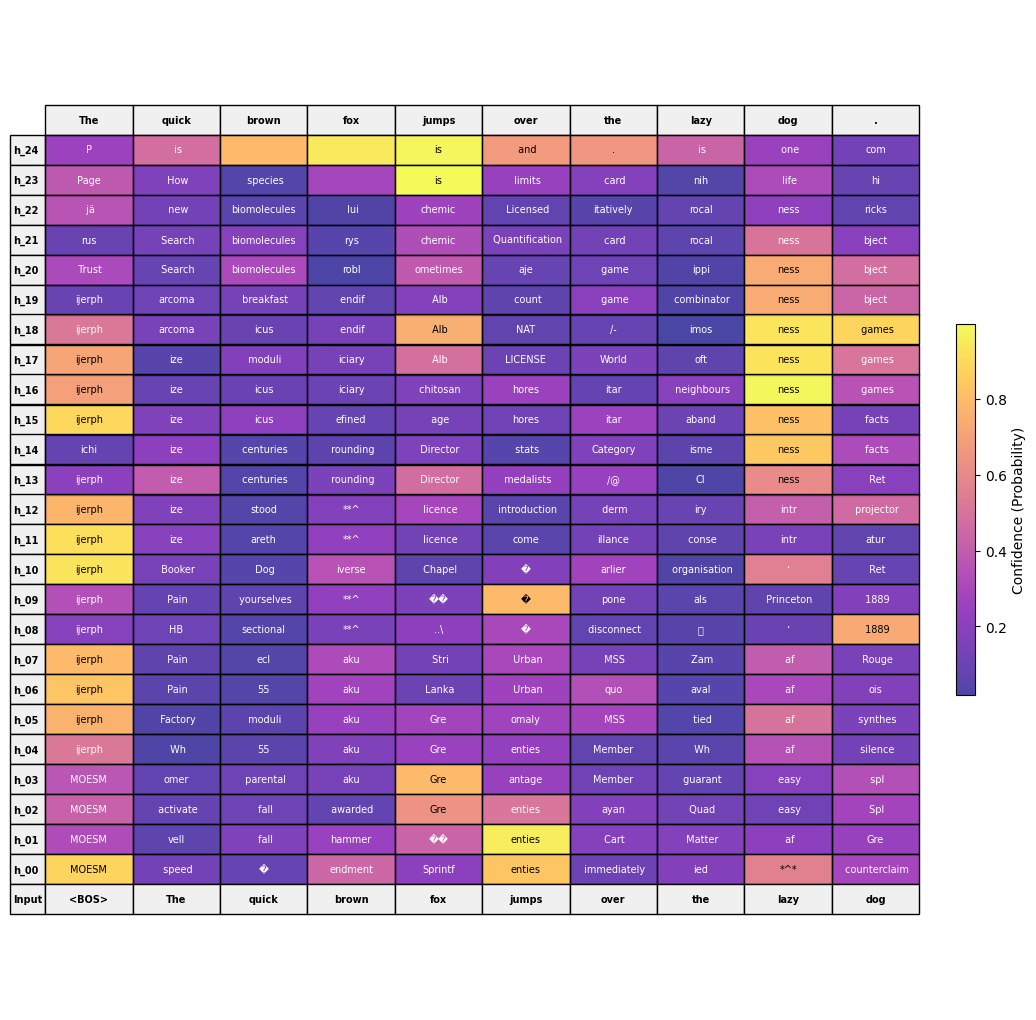


--- Experiment 2: Extract Target Ranks & Probs ---


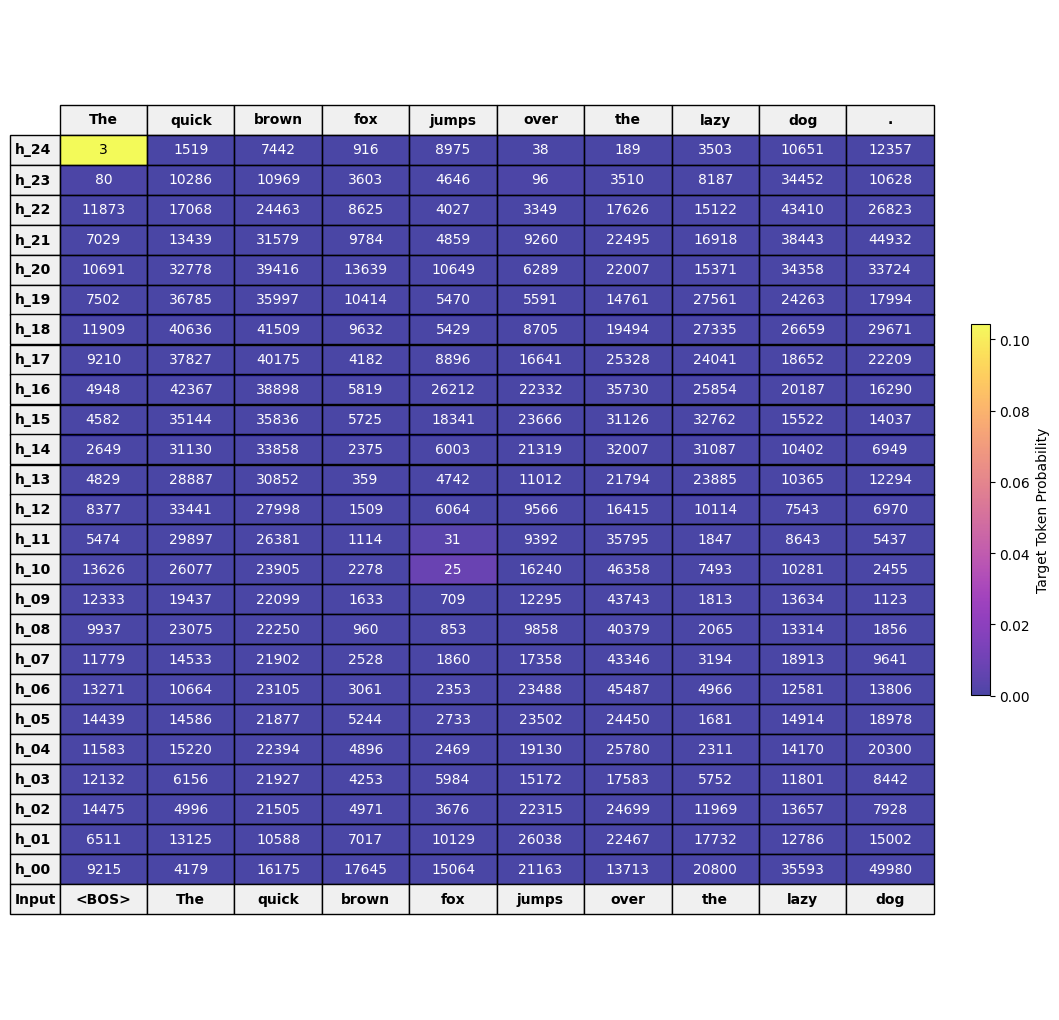


--- Experiment 3: Extract KL Divergences ---


C:\Users\flavi\AppData\Local\Temp\ipykernel_7364\3987249204.py:62: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  plt.savefig("./hidden_vs_outpout_KL.png")


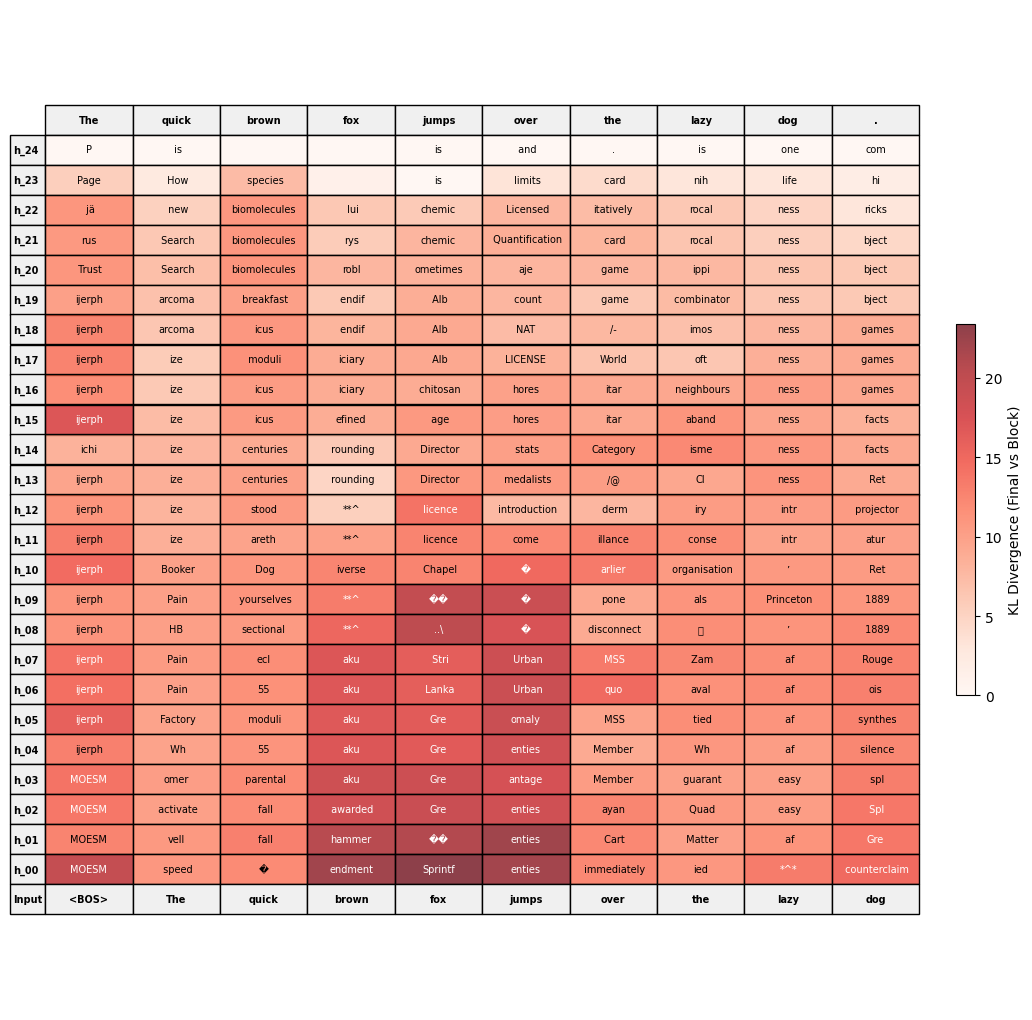

In [ ]:
import torch
import torch.nn as nn

n = 10  # <-- Change this to define how many of the last blocks to use!

# 1. Back up the full model blocks just in case we want them later
if not hasattr(model.backbone, 'full_blocks'):
    model.backbone.full_blocks = model.backbone.blocks

# 2. Prune the model architecture: Keep ONLY the last n blocks
model.backbone.blocks = nn.ModuleList(list(model.backbone.full_blocks)[-n:])

# 3. Re-run the forward pass with the pruned model
print(f"Executing forward pass on pruned model (Embeddings -> Last {n} Blocks -> LM Head)...")
with torch.no_grad():
    outputs = model(tokens_with_bos, output_hidden_states=True)

# outputs.hidden_states has length n + 1 (embeddings + n block outputs)
# We drop the embeddings to pass only the n block outputs to our functions
pruned_hidden_states = outputs.hidden_states[1:] 

# 4. Run your 3 experiments and plot the results
print("\n--- Experiment 1: Extract Top Tokens ---")
top_token_per_block, top_logits_per_block = extract_top_tokens(LM_HEAD, FINAL_NORM, pruned_hidden_states, False)
plot_table(top_token_per_block, top_logits_per_block, False)

print("\n--- Experiment 2: Extract Target Ranks & Probs ---")
# target_ids should already be defined as inputs[0]
ranks_per_block, probs_per_block = extract_target_ranks_and_probs(LM_HEAD, FINAL_NORM, pruned_hidden_states, inputs[0], False)
plot_rank_table(ranks_per_block, probs_per_block, False)

print("\n--- Experiment 3: Extract KL Divergences ---")
kl_per_block = extract_kl_divergences(LM_HEAD, FINAL_NORM, pruned_hidden_states, False)
plot_kl_table(top_token_per_block, kl_per_block, False)
